**Importing Librabries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/2026DS Plan/data/diabetes data/diabetes.csv")
data.head()
# it has 9 levels (columns)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
data.shape

(768, 9)

In [ ]:
print("number of  rows in the data is = ", data.shape[0])
print("number of columns in the data is =", data.shape[1])

number of  rows in the data is =  768
number of columns in the data is = 9


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
data['Pregnancies'].value_counts()

,count
Pregnancies,
1,135
0,111
2,103
3,75
4,68
5,57
6,50
7,45
8,38


In [ ]:
data['Pregnancies'].max()

17

In [ ]:
data['Pregnancies'].min()

0

In [ ]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
data.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [ ]:
data.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [ ]:
#we see that Pregnancies level is a object but mentioned as int64
#now we are changing it to object.
#Dealng with data inconsistancy

data['Pregnancies'] = data['Pregnancies'].astype("object")

In [ ]:
data.dtypes

,0
Pregnancies,object
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [ ]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
 # seperate catogircal data and numerical data

catogrical, numerical = [], []

for i in data.columns:
  if data[i].dtypes == "object":
    catogrical.append(i)


  else:
    numerical.append(i)

In [ ]:
for i in catogrical:
  print(i)

Pregnancies


In [ ]:
for i in numerical:
  print(i)

Glucose
BloodPressure
SkinThickness
Insulin
BMI
DiabetesPedigreeFunction
Age
Outcome


# **Uni-Variate analysis**

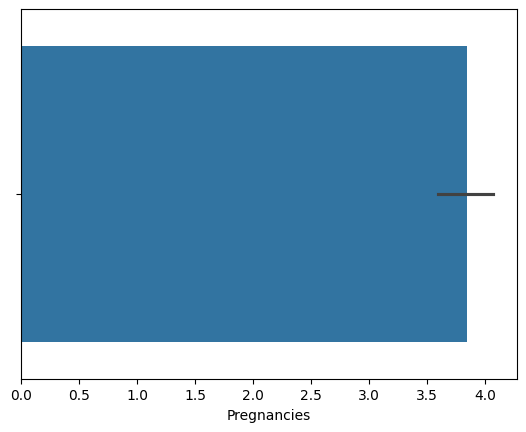

In [ ]:
sns.barplot(x = data['Pregnancies'])
plt.show();

AttributeError: module 'seaborn' has no attribute 'piechart'

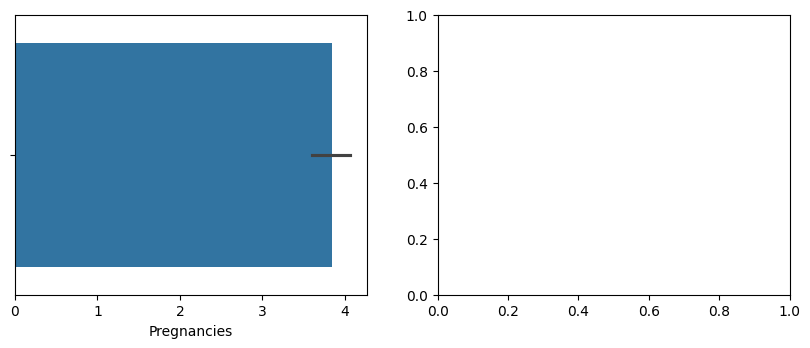

In [ ]:
for i in catogrical:
  plt.figure(figsize=[10,8])
  plt.subplot(2,2,1)
  sns.barplot(x = data[i])
  plt.subplot(2,2,2)
  sns.piechart(x = data[i],label = label)
  plt.show();

In [ ]:
for i in catogrical:
  print("The Top 10 categroies of {}".format(i))
  print(data[i].value_counts().sort_values(ascending = False).head(10))
  index = data[i].value_counts().sort_values(ascending = False).head(10).index
  values = data[i].value_counts().sort_values(ascending = False).head(10).values
  plt.figure(figsize = (8,6))
  plt.pie(values, labels = index, autopct = "%1.2f%%")
  plt.xlabel(i)
  plt.ylabel("the count of {}".format(i))
  plt.title("Top 10 value count {}".format(i))
  plt.grid()
  plt.show()
  print("*"*50)

In [ ]:
for i in catogrical:
  values = data[i].value_counts().sort_values(ascending = True).values
  index  = data[i].value_counts().sort_values(ascending = True).index

print(values)
print(index)

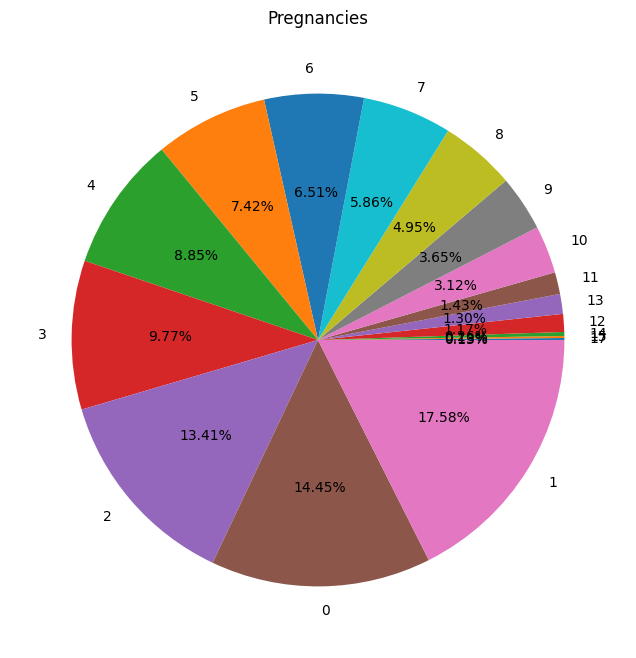

In [ ]:
for i in catogrical:
  (data[i].value_counts().sort_values(ascending = True)).head(5)
  values = data[i].value_counts().sort_values(ascending = True).values
  index  = data[i].value_counts().sort_values(ascending = True).index
  plt.figure(figsize = [10,8])
  plt.subplots = (1,2,1)
  plt.pie(values, labels = index, autopct = "%1.2f%%")
  plt.title(i)
  plt.grid()
  plt.show();



In [ ]:
data.dtypes

,0
Pregnancies,object
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [ ]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
data['Glucose'].value_counts().sort_values(ascending = False).head()

,count
Glucose,
99,17
100,17
111,14
125,14
129,14


In [ ]:
data['Glucose'].value_counts().sort_values(ascending = False).index

Index([ 99, 100, 111, 125, 129, 106, 102, 105, 112,  95,
       ...
       186, 172, 198,  67, 199,  56, 169, 149,  65, 190],
      dtype='int64', name='Glucose', length=136)

In [ ]:
data['Glucose'].value_counts().sort_values(ascending = False).values

array([17, 17, 14, 14, 14, 14, 13, 13, 13, 13, 13, 12, 12, 11, 11, 11, 11,
       11, 11, 11, 11, 10, 10,  9,  9,  9,  9,  9,  9,  9,  9,  9,  8,  8,
        8,  8,  8,  7,  7,  7,  7,  7,  7,  7,  7,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  5,  5,  5,  5,  5,  5,  5,  5,  5,
        5,  5,  5,  5,  5,  5,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [ ]:
# saperating categorical and numerical data.

categorical_col, numerical_ol = [], []

for i in data.columns:
  if data[i].dtypes =="object":
    categorical_col.append(i)

  elif data[i].dtypes != "object":
    numerical_ol.append(i)


In [ ]:
categorical_col

['Pregnancies']

In [ ]:
numerical_ol

['Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

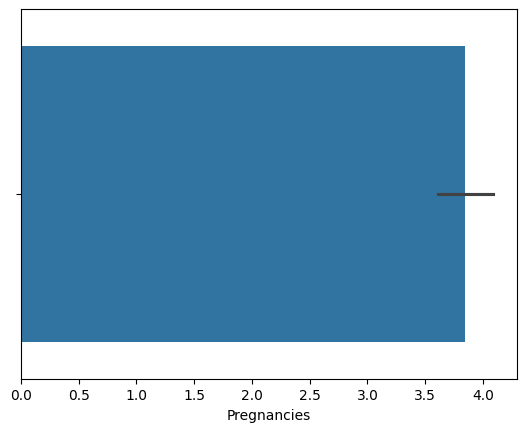

In [ ]:
for i in categorical_col:
  sns.barplot(x = data[i])
  plt.show();

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64


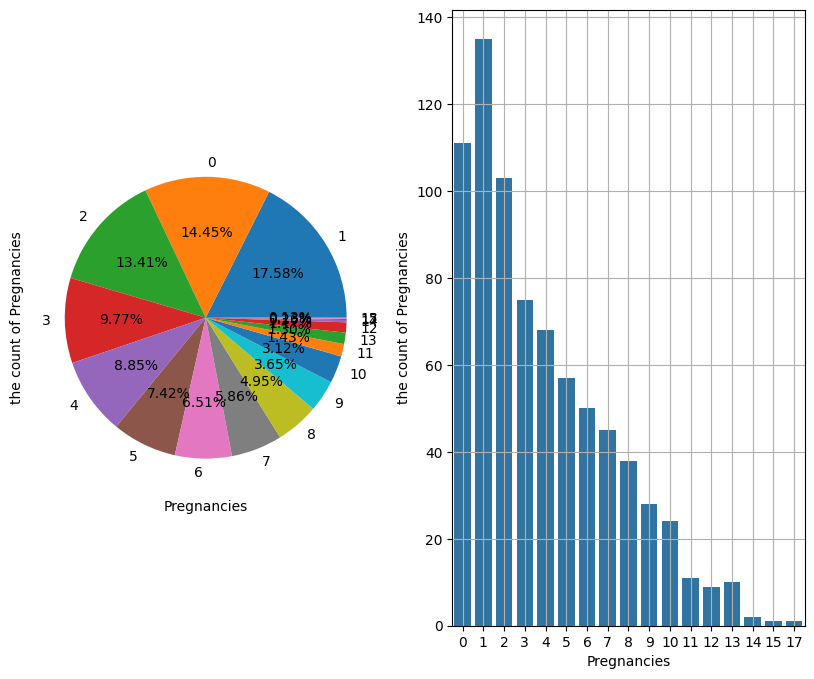

In [ ]:
for i in categorical_col:
  print(data[i].value_counts().sort_values(ascending = False))
  value = (data[i].value_counts().sort_values(ascending = False)).values
  index = (data[i].value_counts().sort_values(ascending = False)).index
  plt.figure(figsize = [10,8])
  plt.subplot(1,2,1)
  plt.pie(value, labels = index, autopct = "%1.2f%%")
  plt.xlabel(i)
  plt.ylabel("the count of {}".format(i))

  plt.subplot(1,2,2)
  sns.barplot(x = index, y = value)
  plt.xlabel(i)
  plt.ylabel("the count of {}".format(i))
  plt.grid()
  plt.show();


In [ ]:
data['Pregnancies'].value_counts().values

array([135, 111, 103,  75,  68,  57,  50,  45,  38,  28,  24,  11,  10,
         9,   2,   1,   1])

In [ ]:
data['Pregnancies'].value_counts().index

Index([1, 0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 12, 14, 17, 15], dtype='object', name='Pregnancies')

/tmp/ipykernel_1217/972349728.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = data['Pregnancies'].value_counts().index,


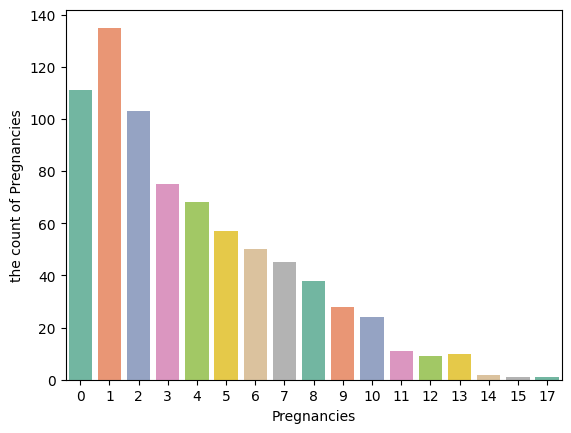

In [ ]:
sns.barplot(x = data['Pregnancies'].value_counts().index,
            y =data['Pregnancies'].value_counts().values,
            palette='Set2' )
plt.xlabel("Pregnancies")
plt.ylabel("the count of Pregnancies")
plt.show();

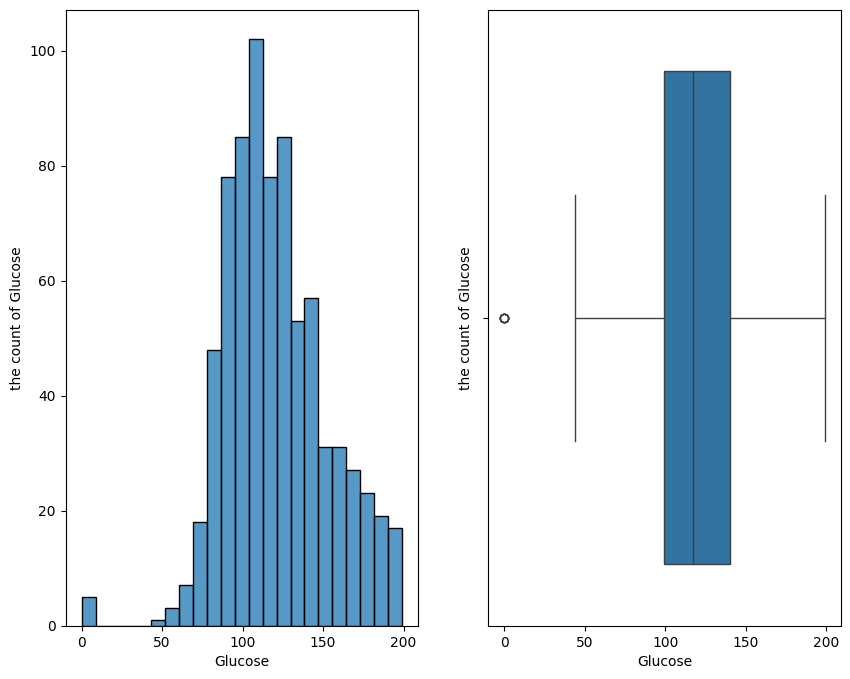

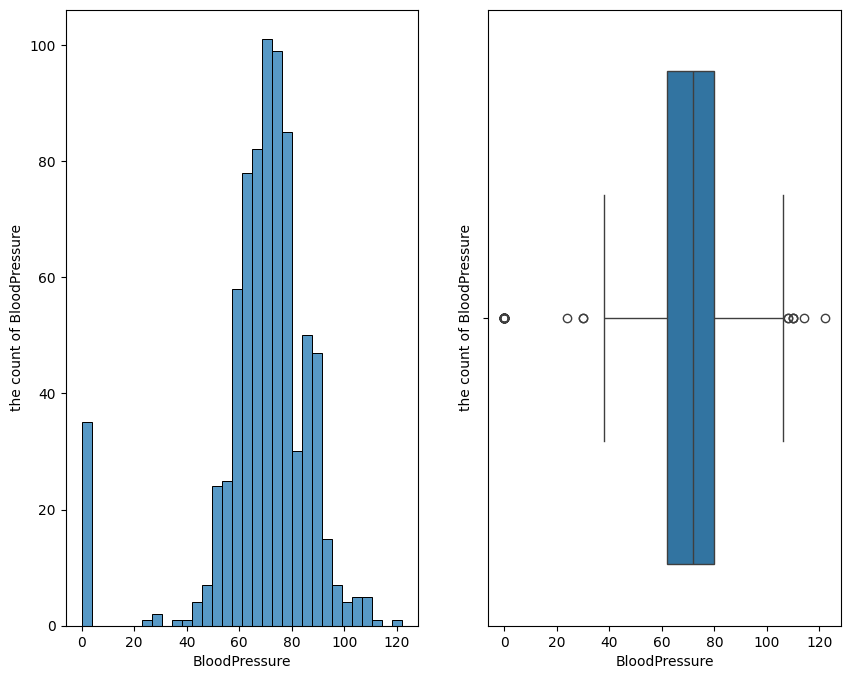

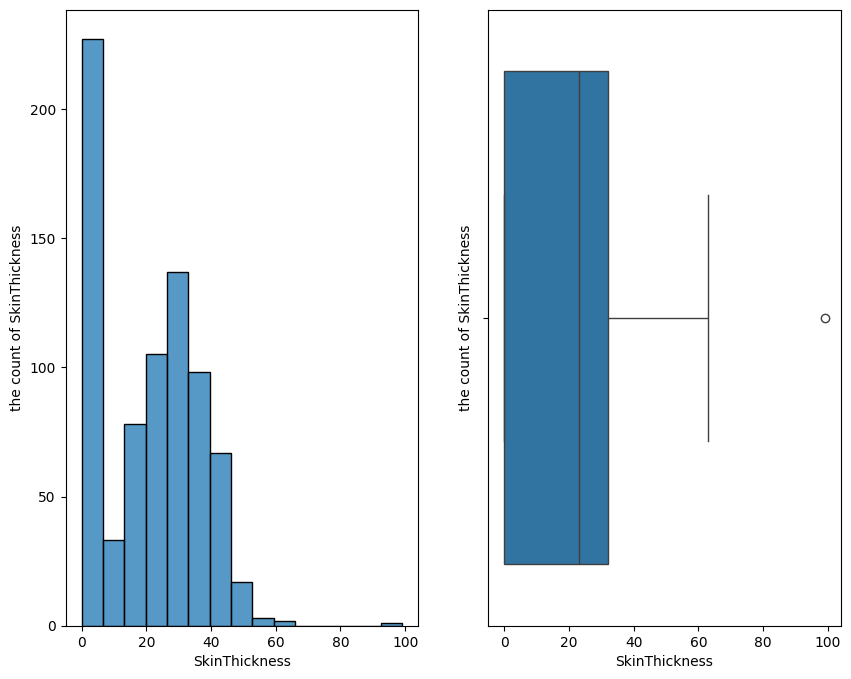

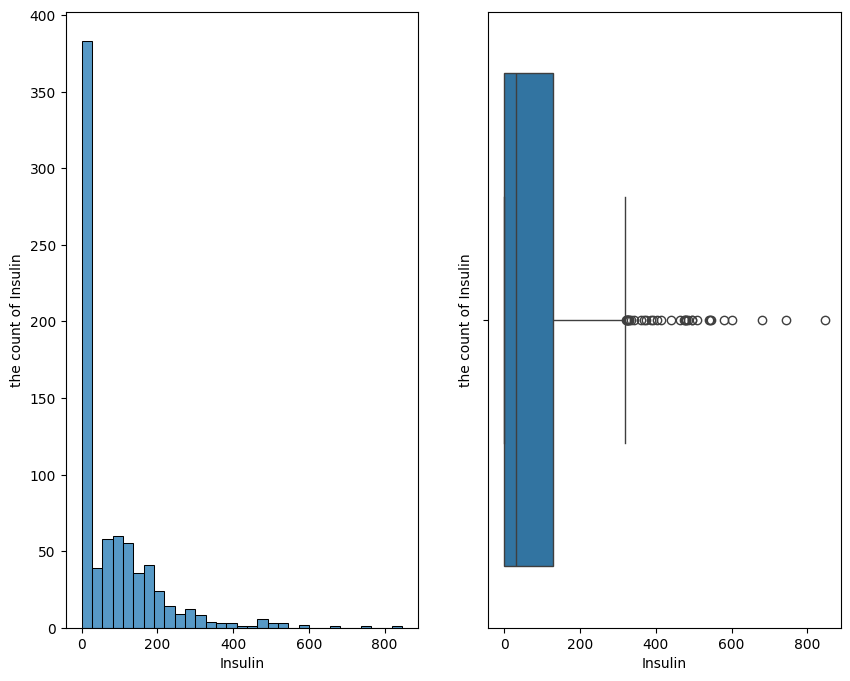

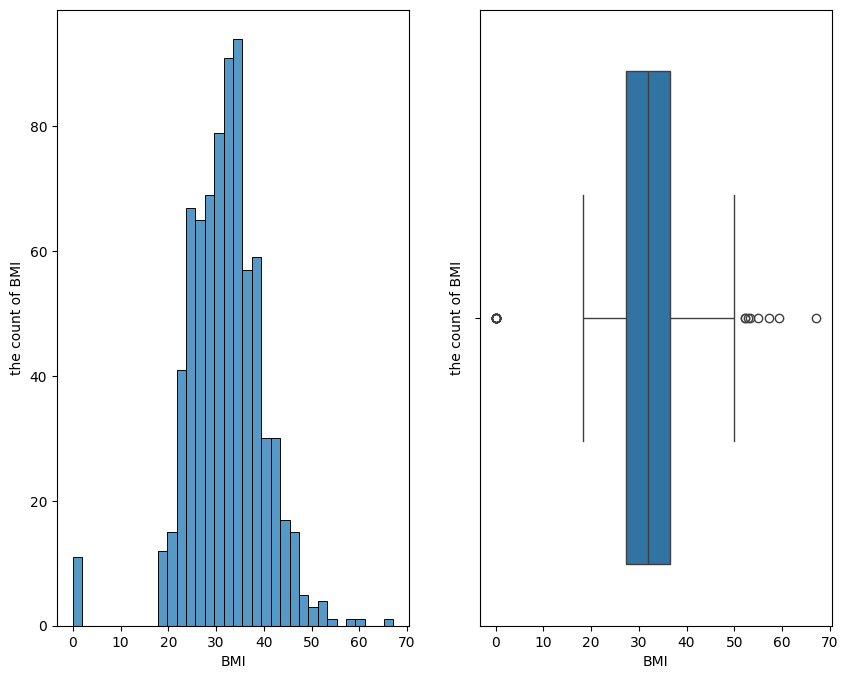

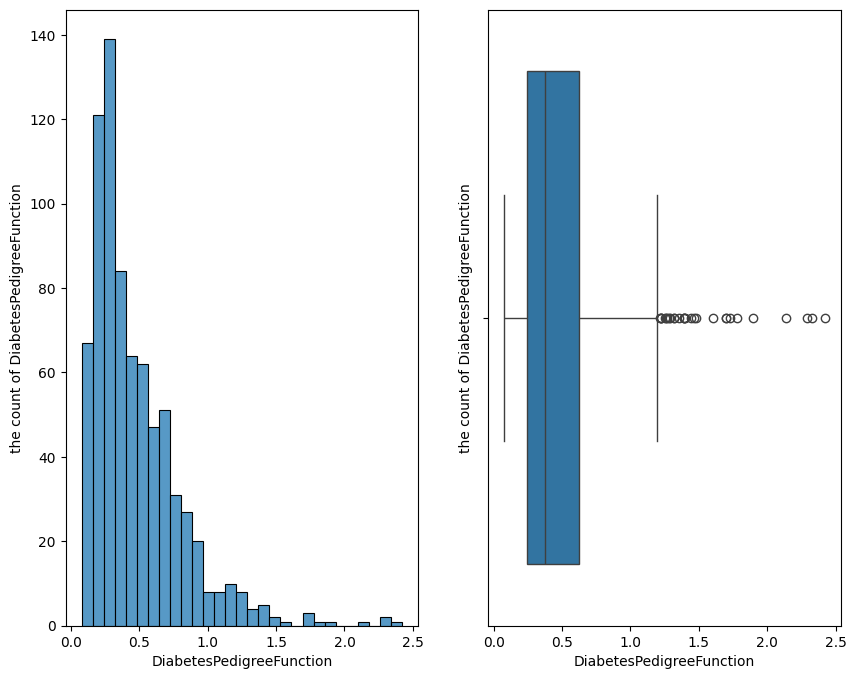

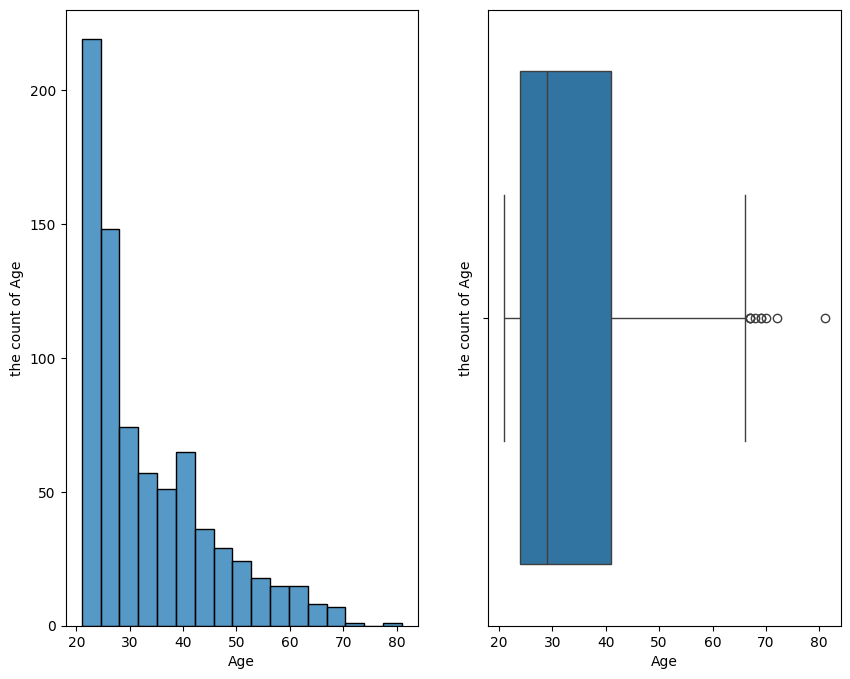

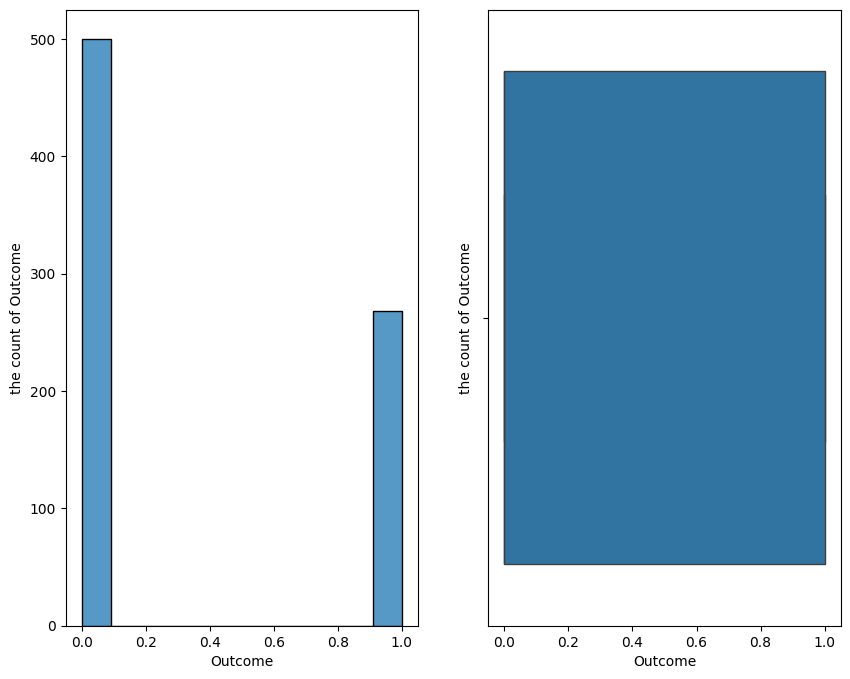

In [ ]:
for i in numerical_ol:
  plt.figure(figsize = [10,8])
  plt.subplot(1,2,1)
  sns.histplot(x = data[i])
  plt.xlabel(i)
  plt.ylabel("the count of {}".format(i))
  plt.subplot(1,2,2)
  sns.boxplot(x = data[i])
  plt.xlabel(i)
  plt.ylabel("the count of {}".format(i))
  plt.show();

# **Modelling**

In [ ]:
data.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
#Separate X and Y
X = data.drop('Outcome', axis= 1)
Y = data['Outcome']

In [ ]:
X.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [ ]:
print(type(Y))

<class 'pandas.core.series.Series'>


In [ ]:
Y.columns

AttributeError: 'Series' object has no attribute 'columns'

In [ ]:
X.shape

(768, 8)

In [ ]:
Y.shape

(768,)

In [ ]:
#import train test split
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2)

In [ ]:
print("X train shape ",X_train.shape)
print("X test shape ",X_test.shape)
print("Y train shape " , Y_train.shape)
print("Y test shape ", Y_test.shape)

X train shape  (614, 8)
X test shape  (154, 8)
Y train shape  (614,)
Y test shape  (154,)


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model =  LogisticRegression()

- Start training
- You tell the model based on the X data what is the corresponding y or target

In [ ]:
model.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
#making predictions

predictions = model.predict(X_test)

In [ ]:
predictions

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0])

In [ ]:
Y_test.values

array([0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0])

In [ ]:
# checking the accuracy of the predtiction

from sklearn.metrics import accuracy_score

print("The accuracy of the logistic regression model is : ",accuracy_score(predictions, Y_test)*100)

The accuracy of the logistic regression model is :  77.92207792207793


In [ ]:
prediction_validation = accuracy_score(predictions, Y_test)*100

In [ ]:
prediction_validation

77.92207792207793

In [ ]:
predictions_train = model.predict(X_train)

In [ ]:
predictions_train_value = accuracy_score(predictions_train, Y_train)*100

In [ ]:
predictions_train_value

77.52442996742671

# **Support Vector Classifier**

In [ ]:
from sklearn.svm import SVC

model_svc = SVC()

In [ ]:
#fitting the model in svc

model_svc.fit(X_train, Y_train)

SVC()

In [ ]:
model_svc_predicton = model_svc.predict(X_test)

In [ ]:
model_svc_validation_score = accuracy_score(model_svc_predicton,Y_test)*100

In [ ]:
model_svc_validation_score

72.72727272727273

In [ ]:
model_svc_predicton_train = model_svc.predict(X_train)

In [ ]:
model_svc_train_score = accuracy_score(model_svc_predicton_train,Y_train)*100

In [ ]:
model_svc_train_score

78.0130293159609

In [ ]:
df =  {"Model_algo": ["model_log_reg_validation",
                      "model_log_reg_training",
                      "model_svc_validation",
                      "model_svc_train"],
      "Scores": [prediction_validation,
                  predictions_train_value,
                  model_svc_validation_score,
                  model_svc_train_score]}


In [ ]:
final_data = pd.DataFrame(df)
final_data

,Model_algo,Scores
0,model_log_reg_validation,74.025974
1,model_log_reg_training,79.153094
2,model_svc_validation,72.727273
3,model_svc_train,78.013029


<Axes: >

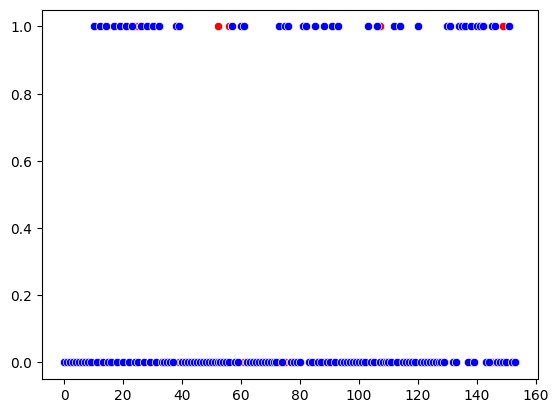

In [ ]:
# ploting graph based on the output for loggistic regression

test_sample_index = range(0,len(Y_test))
train_sample_index = range(0,len(Y_train))
sns.scatterplot(x= test_sample_index, y =model_svc_predicton, color = "r" )
sns.scatterplot(x= test_sample_index, y =predictions, color = "b" )

<Axes: >

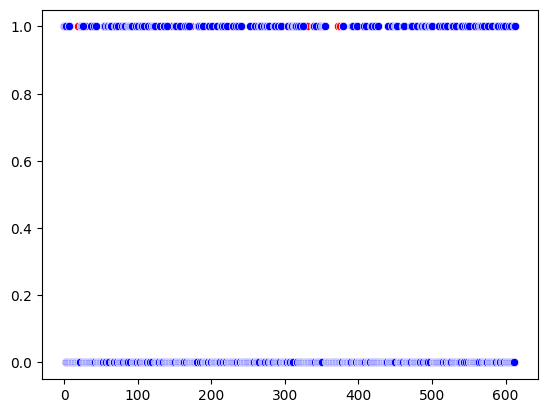

In [ ]:
test_sample_index = range(0,len(Y_test))
train_sample_index = range(0,len(Y_train))
sns.scatterplot(x= train_sample_index, y =predictions_train, color = "r" )
sns.scatterplot(x= train_sample_index, y =model_svc_predicton_train, color = "b" )

# **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
decision_tree = DecisionTreeClassifier()

In [ ]:
#starting the training

decision_tree.fit(X_train, Y_train)

DecisionTreeClassifier()

In [ ]:
dt_prediction = decision_tree.predict(X_test)

In [ ]:
dt_prediction

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0])

In [ ]:
dt_prediction_result = accuracy_score(dt_prediction, Y_test)*100

In [ ]:
dt_prediction_result

In [ ]:
# Performing hyperparameter tunning

from sklearn.model_selection import GridSearchCV , RandomizedSearchCV


In [ ]:
param_grid_dt = {"criterion":["gini", "entropy", "log_loss"],
              "splitter":["best", "random"],
              "max_features":["auto","sqrt", "log2"],
              }
grid_search = GridSearchCV(estimator= decision_tree,
                           param_grid =param_grid_dt,
                           n_jobs = -1,
                           scoring = "r2")

In [ ]:
grid_search.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
18 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

GridSearchCV(estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='r2')

In [ ]:
grid_search.best_estimator_

DecisionTreeClassifier(criterion='log_loss', max_features='log2')

In [ ]:
grid_search.best_params_

{'criterion': 'log_loss', 'max_features': 'log2', 'splitter': 'best'}

In [ ]:
decision_tree_tunned = DecisionTreeClassifier(criterion = 'log_loss',
                                       max_features = 'log2',
                                       splitter = 'best')

In [ ]:
decision_tree_tunned_fitd = decision_tree_tunned.fit(X_train,Y_train)

In [ ]:
decision_tree_tunned_fitd

DecisionTreeClassifier(criterion='log_loss', max_features='log2')

In [ ]:
dt_predictions_final = decision_tree_tunned_fitd.predict(X_test)

In [ ]:
dt_predictions_pred_result = accuracy_score(dt_predictions_final, Y_test)*100

In [ ]:
dt_predictions_pred_result

71.42857142857143

In [ ]:
param_random_dt = {"criterion":["gini", "entropy", "log_loss"],
              "splitter":["best", "random"],
              "max_features":["auto","sqrt", "log2"],
              }
random_search = RandomizedSearchCV(estimator = decision_tree,
                                   param_distributions =param_random_dt,
                                   scoring= "r2",
                                   n_jobs = -1)

In [ ]:
random_search.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_p

RandomizedSearchCV(estimator=DecisionTreeClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'splitter': ['best', 'random']},
                   scoring='r2')

In [ ]:
random_search.best_params_

{'splitter': 'best', 'max_features': 'log2', 'criterion': 'gini'}

In [ ]:
decision_tree_ran = DecisionTreeClassifier(splitter = 'best',
                                       max_features = 'log2',
                                       criterion =  'entropy')

In [ ]:
decision_tree_ran.fit(X_train,Y_train)

DecisionTreeClassifier(criterion='entropy', max_features='log2')

In [ ]:
decision_tree_ran_pred = decision_tree_ran.predict(X_test)

In [ ]:
decision_tree_ran_pred_result = accuracy_score(decision_tree_ran_pred, Y_test)*100

In [ ]:
decision_tree_ran_pred_result

68.83116883116884

In [ ]:
data_final_score  = {"dt_algo":["Decison_tree_pred_score",
                                "Decison_tree_pred_score_grid",
                                "Decison_tree_pred_score_random"],
                     "Scores":[dt_prediction_result,
                               dt_predictions_pred_result,
                               decision_tree_ran_pred_result]}


In [ ]:
data_scores = pd.DataFrame(data_final_score)

In [ ]:
data_scores

,dt_algo,Scores
0,Decison_tree_pred_score,62.987013
1,Decison_tree_pred_score_grid,71.428571
2,Decison_tree_pred_score_random,68.831169


# **Ensemble Learning**

In [ ]:
# Random forest classifier

In [ ]:
from sklearn.ensemble import  RandomForestClassifier

In [ ]:
random_forest = RandomForestClassifier()

In [ ]:
random_forest.fit(X_train,Y_train)

RandomForestClassifier()

In [ ]:
#getting predictions from the model

random_forest_pred = random_forest.predict(X_test)
random_forest_pred_train = random_forest.predict(X_train)

In [ ]:
random_forest_pred_score = accuracy_score(random_forest_pred,Y_test)*100

In [ ]:
random_forest_pred_score

71.42857142857143

In [ ]:
random_forest_pred_train_score  = accuracy_score(random_forest_pred_train,Y_train)*100

In [ ]:
random_forest_pred_train_score

100.0

# **Hyperparater tunning (RF)**

In [ ]:
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV

# entering the parameter of random forest
param_grid_Rf = {"n_estimators":[100,200,300],
                 "criterion":["gini", "entropy", "log_loss"],
                 "max_depth":[1,2,3,4,5,6,7,8,9,10],
                 "max_features":["None","sqrt", "log2"]
                 }

#entering grid search parameters
grid_search_rf = GridSearchCV(estimator= random_forest,
                           param_grid =param_grid_Rf,
                           n_jobs = -1,
                           scoring = "r2")
#entering random search parameters
random_search_rf = RandomizedSearchCV(estimator = random_forest,
                                   param_distributions =param_grid_Rf,
                                   scoring= "r2",
                                   n_jobs = -1)
# fitting the model
grid_search_rf.fit(X_train, Y_train)
random_search_rf.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
450 fits failed out of a total of 1350.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
251 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/uti

RandomizedSearchCV(estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10],
                                        'max_features': ['None', 'sqrt',
                                                         'log2'],
                                        'n_estimators': [100, 200, 300]},
                   scoring='r2')

In [ ]:
grid_search_rf.best_params_

{'criterion': 'gini',
 'max_depth': 4,
 'max_features': 'sqrt',
 'n_estimators': 200}

In [ ]:
random_search_rf.best_params_

{'n_estimators': 100,
 'max_features': 'sqrt',
 'max_depth': 8,
 'criterion': 'log_loss'}

In [ ]:
grid_search_rf_tuned = RandomForestClassifier(criterion = 'entropy',
                                              max_depth =  6,
                                              max_features =  'log2',
                                              n_estimators =  100)

In [ ]:
random_search_rf_tuned = RandomForestClassifier(criterion = 'log_loss',
                                              max_depth =  9,
                                              max_features =  'sqrt',
                                              n_estimators =  300)

In [ ]:
grid_search_rf_tuned.fit(X_train,Y_train)


RandomForestClassifier(criterion='entropy', max_depth=6, max_features='log2')

In [ ]:
random_search_rf_tuned.fit(X_train,Y_train)

RandomForestClassifier(criterion='log_loss', max_depth=9, n_estimators=300)

In [ ]:
grid_search_rf_tuned_pred = grid_search_rf_tuned.predict(X_test)
random_search_rf_tuned_pred = random_search_rf_tuned.predict(X_test)

In [ ]:
grid_search_rf_tuned_pred_score = accuracy_score(grid_search_rf_tuned_pred,Y_test)*100
random_search_rf_tuned_pred_score = accuracy_score(random_search_rf_tuned_pred,Y_test)*100

In [ ]:
grid_search_rf_tuned_pred_score

72.07792207792207

In [ ]:
random_search_rf_tuned_pred_score

74.67532467532467

In [ ]:
grid_search_rf_tuned_pred_train = grid_search_rf_tuned.predict(X_train)
random_search_rf_tuned_pred_train = random_search_rf_tuned.predict(X_train)

In [ ]:
grid_search_rf_tuned_pred_score_train = accuracy_score(grid_search_rf_tuned_pred_train,Y_train)*100
random_search_rf_tuned_pred_score_train = accuracy_score(random_search_rf_tuned_pred_train,Y_train)*100

In [ ]:
grid_search_rf_tuned_pred_score_train

89.25081433224756

In [ ]:
random_search_rf_tuned_pred_score_train

99.3485342019544

In [ ]:
data_RF =  {"Model":["RF_Base","RF_GSCV","RF_RSCV"],
            "Train_score":[random_forest_pred_train_score,
                            grid_search_rf_tuned_pred_score_train,
                            random_search_rf_tuned_pred_score_train],
            "prediction_score":[random_forest_pred_score,
                                grid_search_rf_tuned_pred_score,
                                random_search_rf_tuned_pred_score]}

In [ ]:
pd.DataFrame(data_RF)

,Model,Train_score,prediction_score
0,RF_Base,100.000000,71.428571
1,RF_GSCV,89.250814,72.077922
2,RF_RSCV,99.348534,74.675325


In [ ]:
87.622150	-75.974026

11.64812400000001

# **Implementing xgbosst and catboost**

In [ ]:
!pip install xgboost
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [ ]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [ ]:
cat_boost_clf = CatBoostClassifier()
xgboost_classifier = XGBClassifier()

In [ ]:
cat_boost_clf.fit(X_train,Y_train)


Learning rate set to 0.008365
0:	learn: 0.6881219	total: 49.5ms	remaining: 49.5s
1:	learn: 0.6840232	total: 52ms	remaining: 25.9s
2:	learn: 0.6794830	total: 54.5ms	remaining: 18.1s
3:	learn: 0.6747131	total: 56.9ms	remaining: 14.2s
4:	learn: 0.6702897	total: 59.3ms	remaining: 11.8s
5:	learn: 0.6655736	total: 61.7ms	remaining: 10.2s
6:	learn: 0.6615088	total: 64.1ms	remaining: 9.09s
7:	learn: 0.6574620	total: 66.4ms	remaining: 8.23s
8:	learn: 0.6530797	total: 68.6ms	remaining: 7.56s
9:	learn: 0.6486909	total: 71ms	remaining: 7.03s
10:	learn: 0.6448974	total: 73.4ms	remaining: 6.6s
11:	learn: 0.6410196	total: 76.2ms	remaining: 6.27s
12:	learn: 0.6375197	total: 78.6ms	remaining: 5.97s
13:	learn: 0.6336579	total: 81ms	remaining: 5.71s
14:	learn: 0.6297600	total: 83.5ms	remaining: 5.48s
15:	learn: 0.6261888	total: 85.8ms	remaining: 5.28s
16:	learn: 0.6221172	total: 88.2ms	remaining: 5.1s
17:	learn: 0.6193517	total: 90.4ms	remaining: 4.93s
18:	learn: 0.6153108	total: 92.7ms	remaining: 4.79s


CatBoostClassifier()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    object 
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 54.1+ KB


In [ ]:
#getting error in xgboost while fitting because pregnanceies is in object catagory
X_train['Pregnancies']  = X_train['Pregnancies'].astype(int)
X_test['Pregnancies']  = X_test['Pregnancies'].astype(int)

In [ ]:
xgboost_classifier.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
cat_boost_clf_predict  = cat_boost_clf.predict(X_test)
xgboost_classifier_predict = xgboost_classifier.predict(X_test)

In [ ]:
cat_boost_clf_predict_score = accuracy_score (cat_boost_clf_predict, Y_test)*100
xgboost_classifier_predict_score = accuracy_score(xgboost_classifier_predict,Y_test)*100

In [ ]:
cat_boost_clf_predict_score

74.02597402597402

In [ ]:
xgboost_classifier_predict_score

70.12987012987013

In [ ]:
cat_boost_clf_predict_train  = cat_boost_clf.predict(X_train)
xgboost_classifier_predict_train = xgboost_classifier.predict(X_train)

In [ ]:
cat_boost_clf_predict_score_train = accuracy_score (cat_boost_clf_predict_train, Y_train)*100
xgboost_classifier_predict_score_train = accuracy_score(xgboost_classifier_predict_train,Y_train)*100

In [ ]:
cat_boost_clf_predict_score_train

96.25407166123779

In [ ]:
xgboost_classifier_predict_score_train

100.0

# **implementing hyperparamters on catboost and xgboost**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [ ]:
#parameters for cat boost
catboost_params = {'iterations': [100, 200],
                   'depth': [4, 6, 8],
                   'learning_rate': [0.01, 0.1]}

catboost_gird = GridSearchCV(estimator= cat_boost_clf,
                             param_grid =catboost_params,
                             n_jobs = -1,
                             scoring = "r2")
catboost_random = RandomizedSearchCV(estimator = cat_boost_clf,
                                   param_distributions =catboost_params,
                                   scoring= "r2",
                                   n_jobs = -1)

In [ ]:
catboost_gird.fit(X_train, Y_train)
catboost_random.fit(X_train, Y_train)

0:	learn: 0.6661497	total: 1.36ms	remaining: 135ms
1:	learn: 0.6437096	total: 2.95ms	remaining: 145ms
2:	learn: 0.6231866	total: 4.09ms	remaining: 132ms
3:	learn: 0.6037635	total: 5.2ms	remaining: 125ms
4:	learn: 0.5883044	total: 6.26ms	remaining: 119ms
5:	learn: 0.5726787	total: 7.38ms	remaining: 116ms
6:	learn: 0.5594139	total: 8.54ms	remaining: 113ms
7:	learn: 0.5484490	total: 9.57ms	remaining: 110ms
8:	learn: 0.5371421	total: 10.6ms	remaining: 107ms
9:	learn: 0.5283104	total: 11.7ms	remaining: 105ms
10:	learn: 0.5177856	total: 12.8ms	remaining: 103ms
11:	learn: 0.5104296	total: 13.8ms	remaining: 101ms
12:	learn: 0.5033527	total: 14.8ms	remaining: 99.2ms
13:	learn: 0.4963755	total: 15.9ms	remaining: 97.8ms
14:	learn: 0.4894771	total: 17ms	remaining: 96.5ms
15:	learn: 0.4825776	total: 18ms	remaining: 94.6ms
16:	learn: 0.4754928	total: 19.1ms	remaining: 93.3ms
17:	learn: 0.4696285	total: 20.2ms	remaining: 92ms
18:	learn: 0.4645339	total: 21.2ms	remaining: 90.4ms
19:	learn: 0.4610074	t

RandomizedSearchCV(estimator=CatBoostClassifier(), n_jobs=-1,
                   param_distributions={'depth': [4, 6, 8],
                                        'iterations': [100, 200],
                                        'learning_rate': [0.01, 0.1]},
                   scoring='r2')

In [ ]:
catboost_gird.best_params_

{'depth': 6, 'iterations': 100, 'learning_rate': 0.1}

In [ ]:
catboost_random.best_params_

{'learning_rate': 0.1, 'iterations': 100, 'depth': 4}

In [ ]:
cat_boost_clf_grid_tunned = CatBoostClassifier(depth= 4,
                                               iterations= 100,
                                               learning_rate =  0.1)

In [ ]:
cat_boost_clf_grid_tunned.fit(X_train,Y_train)

0:	learn: 0.6638941	total: 647us	remaining: 64.1ms
1:	learn: 0.6401544	total: 1.2ms	remaining: 58.6ms
2:	learn: 0.6211897	total: 1.67ms	remaining: 53.9ms
3:	learn: 0.6022610	total: 2.19ms	remaining: 52.4ms
4:	learn: 0.5846289	total: 2.66ms	remaining: 50.5ms
5:	learn: 0.5715826	total: 3.11ms	remaining: 48.7ms
6:	learn: 0.5582981	total: 3.62ms	remaining: 48.1ms
7:	learn: 0.5479303	total: 4.12ms	remaining: 47.3ms
8:	learn: 0.5372393	total: 4.58ms	remaining: 46.3ms
9:	learn: 0.5291142	total: 5.04ms	remaining: 45.4ms
10:	learn: 0.5221103	total: 5.57ms	remaining: 45.1ms
11:	learn: 0.5130430	total: 6.03ms	remaining: 44.2ms
12:	learn: 0.5039027	total: 6.5ms	remaining: 43.5ms
13:	learn: 0.4981359	total: 6.96ms	remaining: 42.8ms
14:	learn: 0.4920487	total: 7.5ms	remaining: 42.5ms
15:	learn: 0.4847954	total: 7.94ms	remaining: 41.7ms
16:	learn: 0.4804650	total: 8.44ms	remaining: 41.2ms
17:	learn: 0.4745559	total: 8.94ms	remaining: 40.7ms
18:	learn: 0.4709019	total: 9.45ms	remaining: 40.3ms
19:	lea

CatBoostClassifier(depth=4, iterations=100, learning_rate=0.1)

In [ ]:
cat_boost_clf_random_tunned = CatBoostClassifier(depth= 4,
                                               iterations= 100,
                                               learning_rate =  0.1)

In [ ]:
cat_boost_clf_random_tunned.fit(X_train,Y_train)

0:	learn: 0.6638941	total: 795us	remaining: 78.8ms
1:	learn: 0.6401544	total: 2.62ms	remaining: 128ms
2:	learn: 0.6211897	total: 3.17ms	remaining: 103ms
3:	learn: 0.6022610	total: 3.68ms	remaining: 88.4ms
4:	learn: 0.5846289	total: 4.59ms	remaining: 87.2ms
5:	learn: 0.5715826	total: 5.44ms	remaining: 85.2ms
6:	learn: 0.5582981	total: 6.06ms	remaining: 80.5ms
7:	learn: 0.5479303	total: 6.56ms	remaining: 75.4ms
8:	learn: 0.5372393	total: 7.04ms	remaining: 71.2ms
9:	learn: 0.5291142	total: 7.7ms	remaining: 69.3ms
10:	learn: 0.5221103	total: 8.41ms	remaining: 68.1ms
11:	learn: 0.5130430	total: 9.04ms	remaining: 66.3ms
12:	learn: 0.5039027	total: 9.69ms	remaining: 64.8ms
13:	learn: 0.4981359	total: 11.8ms	remaining: 72.3ms
14:	learn: 0.4920487	total: 12.6ms	remaining: 71.3ms
15:	learn: 0.4847954	total: 13.4ms	remaining: 70.2ms
16:	learn: 0.4804650	total: 14.2ms	remaining: 69.5ms
17:	learn: 0.4745559	total: 15.1ms	remaining: 68.8ms
18:	learn: 0.4709019	total: 16ms	remaining: 68.3ms
19:	learn

CatBoostClassifier(depth=4, iterations=100, learning_rate=0.1)

In [ ]:
cat_boost_clf_grid_tunned_pred = cat_boost_clf_grid_tunned.predict(X_test)
cat_boost_clf_random_tunned_pred = cat_boost_clf_random_tunned.predict(X_test)

In [ ]:
cat_boost_clf_grid_tunned_pred_score = accuracy_score(cat_boost_clf_grid_tunned_pred,Y_test)*100
cat_boost_clf_random_tunned_pred_score = accuracy_score(cat_boost_clf_random_tunned_pred,Y_test)*100

In [ ]:
cat_boost_clf_grid_tunned_pred_score

71.42857142857143

In [ ]:
cat_boost_clf_random_tunned_pred_score

71.42857142857143

In [ ]:
cat_boost_clf_grid_tunned_train = cat_boost_clf_grid_tunned.predict(X_train)
cat_boost_clf_random_tunned_train = cat_boost_clf_random_tunned.predict(X_train)

In [ ]:
cat_boost_clf_grid_tunned_train_score = accuracy_score(cat_boost_clf_grid_tunned_train,Y_train)*100
cat_boost_clf_random_tunned_train_score = accuracy_score(cat_boost_clf_random_tunned_train,Y_train)*100

In [ ]:
cat_boost_clf_grid_tunned_train_score

84.69055374592834

In [ ]:
cat_boost_clf_random_tunned_train_score

84.69055374592834

In [ ]:
    catboostdf = {"models":["Catb_base_predict",
                          "catb_grid predict",
                          "catb_random predict"],
                "predict score":[cat_boost_clf_predict_score,
                                  cat_boost_clf_grid_tunned_pred_score,
                                  cat_boost_clf_random_tunned_pred_score],
                "trained predict score":[cat_boost_clf_predict_score_train,
                                          cat_boost_clf_grid_tunned_train_score,
                                          cat_boost_clf_random_tunned_train_score]
                }

In [ ]:
catboost_report =pd.DataFrame(catboostdf)
catboost_report

,models,predict score,trained predict score
0,Catb_base_predict,74.025974,96.254072
1,catb_grid predict,71.428571,84.690554
2,catb_random predict,71.428571,84.690554


In [ ]:
#parameters for XGboost
param_grid_xgboost = {'n_estimators': [100, 200, 300],
                      'learning_rate': [0.01, 0.05, 0.1],
                      'max_depth': [3, 5, 7],
                      'subsample': [0.8, 1.0],
                      'colsample_bytree': [0.8, 1.0]
                      }

xgboost_gird = GridSearchCV(estimator= xgboost_classifier,
                            param_grid =param_grid_xgboost,
                            n_jobs = -1,
                            scoring = "r2",
                            cv =5)
xgboost_random = RandomizedSearchCV(estimator = xgboost_classifier,
                                    param_distributions =param_grid_xgboost,
                                    scoring= "r2",
                                    n_jobs = -1,
                                    cv =5)

In [ ]:
xgboost_gird.fit(X_train,Y_train)
xgboost_random.fit(X_train,Y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   scoring='r2')

In [ ]:
xgboost_gird.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.01,
 'max_depth': 5,
 'n_estimators': 300,
 'subsample': 0.8}

In [ ]:
xgboost_gird.best_score_

np.float64(-0.023141050229657734)

In [ ]:
xgboost_random.best_params_


{'subsample': 0.8,
 'n_estimators': 200,
 'max_depth': 3,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [ ]:
xgboost_random.best_score_


np.float64(-0.04402958504224317)

In [ ]:
xgboost_gird_pred = xgboost_gird.predict(X_test)
xgboost_random_pred = xgboost_random.predict(X_test)

In [ ]:
xgboost_gird_pred_score = accuracy_score(xgboost_gird_pred,Y_test)*100
xgboost_random_pred_score = accuracy_score(xgboost_random_pred,Y_test)*100

In [ ]:
xgboost_gird_pred_score

70.77922077922078

In [ ]:
xgboost_random_pred_score

75.32467532467533

In [ ]:
xgboost_gird_train = xgboost_gird.predict(X_train)
xgboost_random_train = xgboost_random.predict(X_train)

In [ ]:
xgboost_gird_train_score = accuracy_score(xgboost_gird_train,Y_train)*100
xgboost_random_train_score = accuracy_score(xgboost_random_train,Y_train)*100

In [ ]:
xgboost_gird_train_score

90.39087947882736

In [ ]:
xgboost_random_train_score

90.71661237785015

In [ ]:
XGBoostdf  =     {"Model":["XGBost_base_score",
                            "XGBost_grid_pred_score",
                            "XGBost_radom_pred_score"],
                  "Trianed Score":[xgboost_classifier_predict_score_train,
                                    xgboost_gird_train_score,
                                    xgboost_random_train_score],
                  "Prediction score":[xgboost_classifier_predict_score,
                                      xgboost_gird_pred_score,
                                      xgboost_random_pred_score]
                  }

In [ ]:
XGBoost_report = pd.DataFrame(XGBoostdf)

# **Final report presentation**

In [ ]:
XGBoost_report

,Model,Trianed Score,Prediction score
0,XGBost_base_score,100.000000,70.129870
1,XGBost_grid_pred_score,90.390879,70.779221
2,XGBost_radom_pred_score,90.716612,75.324675


In [ ]:
pd.DataFrame(data_RF)

,Model,Train_score,prediction_score
0,RF_Base,100.000000,71.428571
1,RF_GSCV,89.250814,72.077922
2,RF_RSCV,99.348534,74.675325


In [ ]:
catboost_report

,models,predict score,trained predict score
0,Catb_base_predict,74.025974,96.254072
1,catb_grid predict,71.428571,84.690554
2,catb_random predict,71.428571,84.690554


In [ ]:
data_scores

,dt_algo,Scores
0,Decison_tree_pred_score,62.987013
1,Decison_tree_pred_score_grid,71.428571
2,Decison_tree_pred_score_random,68.831169


In [ ]:
final_data

,Model_algo,Scores
0,model_log_reg_validation,74.025974
1,model_log_reg_training,79.153094
2,model_svc_validation,72.727273
3,model_svc_train,78.013029


# **Final Obseration**
After I trained all the models including logistic regression, SVC, decision tree, Random forest,XGBoost and catboost. i compared with both validation score and trained data score. Whle some model scored 100 accuracy, uses a overfitting. The Random forest tunned Grid SearchCV better in both training 89.25% an prediction of 72.07%. So , I have selected it as a final model   

In [ ]:
# Checking other metrics in random forest tunned grid search model

# importing metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Predict
y_pred = grid_search_rf.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(Y_test, y_pred)*100)
print("Precision:", precision_score(Y_test, y_pred)*100)
print("Recall   :", recall_score(Y_test, y_pred)*100)
print("F1 Score :", f1_score(Y_test, y_pred)*100)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(Y_test, y_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(Y_test, y_pred))

Accuracy : 75.32467532467533
Precision: 61.111111111111114
Recall   : 47.82608695652174
F1 Score : 53.65853658536586

Confusion Matrix
[[94 14]
 [24 22]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       108
           1       0.61      0.48      0.54        46

    accuracy                           0.75       154
   macro avg       0.70      0.67      0.68       154
weighted avg       0.74      0.75      0.74       154



In [ ]:
print(Y.value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
# entering the parameter of random forest
param_grid_Rf_1 = {'n_estimators': [200, 300, 500],
                 'max_depth': [5, 10, 15],
                 'min_samples_split': [2, 5, 10],
                 'min_samples_leaf': [1, 2, 4],
                 'class_weight': [None, 'balanced']
                 }

#entering grid search parameters
grid_search_rf_1 = GridSearchCV(estimator= random_forest,
                           param_grid =param_grid_Rf_1,
                           n_jobs = -1,
                           scoring = "recall")

In [ ]:
Y_train.shape

(614,)

In [ ]:
grid_search_rf_1.fit(X_train,Y_train)

GridSearchCV(estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [200, 300, 500]},
             scoring='recall')

In [ ]:
best_model = grid_search_rf_1.best_estimator_
best_model

RandomForestClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=4,
                       n_estimators=200)

In [ ]:
grid_search_rf_1.best_params_

{'class_weight': 'balanced',
 'max_depth': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 200}

In [ ]:
grid_search_rf_tuned_1 = RandomForestClassifier(class_weight= 'balanced',
                                                max_depth= 5,
                                                min_samples_leaf= 4,
                                                min_samples_split= 2,
                                                n_estimators = 200)

In [ ]:
grid_search_rf_tuned_1.fit(X_train,Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=4,
                       n_estimators=200)

In [ ]:
grid_search_rf_tuned_1_pred = grid_search_rf_tuned_1.predict(X_test)

In [ ]:
grid_search_rf_tuned_1_pred_score = accuracy_score(grid_search_rf_tuned_1_pred,Y_test)*100

In [ ]:
grid_search_rf_tuned_1_pred_score

70.12987012987013

In [ ]:
grid_search_rf_tuned_1_train = grid_search_rf_tuned_1.predict(X_train)
grid_search_rf_tuned_1__train_score = accuracy_score(grid_search_rf_tuned_1_train,Y_train)*100

In [ ]:
grid_search_rf_tuned_1__train_score

84.52768729641694

In [ ]:
rf_rcall = recall_score(Y_test,grid_search_rf_tuned_1_pred)*100

In [ ]:
rf_rcall

67.3913043478261

In [ ]:
# Metrics
print("accuracy_ score:", accuracy_score(grid_search_rf_tuned_1_pred, Y_test)*100)
print("Precision:", precision_score(Y_test, grid_search_rf_tuned_1_pred)*100)
print("Recall   :", recall_score(Y_test, grid_search_rf_tuned_1_pred)*100)
print("F1 Score :", f1_score(Y_test, grid_search_rf_tuned_1_pred)*100)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(Y_test, grid_search_rf_tuned_1_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(Y_test, grid_search_rf_tuned_1_pred))

accuracy_ score: 70.12987012987013
Precision: 50.0
Recall   : 67.3913043478261
F1 Score : 57.407407407407405

Confusion Matrix
[[77 31]
 [15 31]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.71      0.77       108
           1       0.50      0.67      0.57        46

    accuracy                           0.70       154
   macro avg       0.67      0.69      0.67       154
weighted avg       0.74      0.70      0.71       154



# **Observation After changing Scoring to recall**
I tuned the Random Forest model using accuracy as the scoring metric. While it achieved 75.32% accuracy, the recall for diabetic patients was only 47.83%, meaning many diabetic cases were missed. Since diabetes prediction is a medical classification problem where identifying positive cases is important, I retuned the model using recall as the optimization metric. **This increased recall to 67.39%, reducing false negatives from 24 to 15, although overall accuracy decreased to 70.13%.**"

# **AUC -ROC Score**

AUC Score: 75.14090177133656


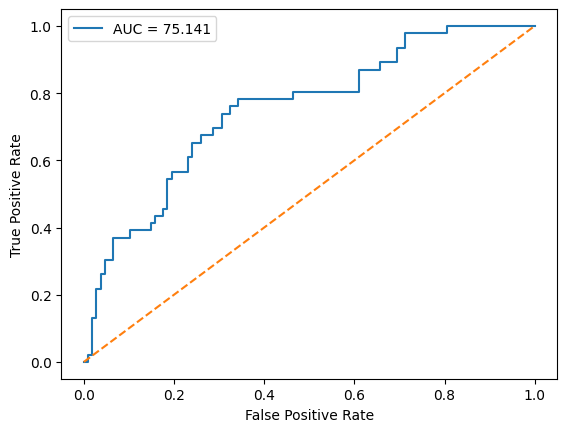

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(Y_test, y_prob)

auc = roc_auc_score(Y_test, y_prob)*100

print("AUC Score:", auc)

plt.plot(fpr, tpr, label="AUC = %.3f" % auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Graph Presentation descrition.

The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate across different classification thresholds. It shows how well the model separates the positive and negative classes. The AUC (Area Under the Curve) summarizes this performance into a single value between 0 and 1. An AUC of 0.5 means the model performs no better than random guessing, while an AUC of 1.0 indicates perfect separation. My Random Forest model achieved an AUC of 0.751, which means it has good ability to distinguish diabetic patients from non-diabetic patients

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_*100
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
1                   Glucose   33.913985
5                       BMI   19.544233
7                       Age   16.139556
0               Pregnancies    7.754486
6  DiabetesPedigreeFunction    6.816093
3             SkinThickness    6.035078
4                   Insulin    5.876532
2             BloodPressure    3.920037


In [ ]:
import joblib

joblib.dump(best_model,"diabetes_rf.pkl")

['diabetes_rf.pkl']

In [ ]:
import os

print(os.listdir())

['.config', 'catboost_info', 'diabetes_rf.pkl', 'drive', 'sample_data']


In [ ]:
from google.colab import files

files.download("diabetes_rf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Predicting on new data**

In [ ]:
data.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


In [ ]:
new_patient = [[
    2,      # Pregnancies
    120,    # Glucose
    70,     # BloodPressure
    25,     # SkinThickness
    80,     # Insulin
    28.5,   # BMI
    0.45,   # DiabetesPedigreeFunction
    35      # Age
]]

In [ ]:
prediction = best_model.predict(new_patient)

print(prediction)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
new_patien_1 = [[
    2,      # Pregnancies
    178,    # Glucose
    70,     # BloodPressure
    25,     # SkinThickness
    80,     # Insulin
    28.5,   # BMI
    0.45,   # DiabetesPedigreeFunction
    35      # Age
]]

pred_1 = best_model.predict(new_patien_1)

print(pred_1)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
X.iloc[[10]]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
10,4,110,92,0,0,37.6,0.191,30


In [ ]:
best_model.predict(X.iloc[[10]])

array([0])

In [ ]:
Y.iloc[10]

np.int64(0)

In [ ]:
X.iloc[[111]]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
111,8,155,62,26,495,34.0,0.543,46


In [ ]:
best_model.predict(X.iloc[[111]])

array([1])

In [ ]:
Y.iloc[111]

np.int64(1)

In [ ]:
prediction = best_model.predict(X.iloc[[111]])

if prediction[0] == 1:
    print("Diabetic")
else:
    print("Non-Diabetic")

Diabetic


In [ ]:
import joblib

joblib.dump(best_model,"diabetes_rf.pkl")

['diabetes_rf.pkl']

In [ ]:
#import joblib

#model = joblib.load("diabetes_rf.pkl")

In [ ]:
from google.colab import files

files.download("diabetes_rf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

best_model = joblib.load("diabetes_rf.pkl")

In [ ]:
import os

print(os.listdir())

['.config', 'diabetes_rf.pkl', 'drive', 'sample_data']


In [ ]:
print(type(best_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [ ]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

In [ ]:
y_prob

array([0.64879645, 0.21204467, 0.71957509, 0.52177934, 0.67255746,
       0.63029377, 0.27396487, 0.09173332, 0.49956722, 0.15282267,
       0.52882626, 0.65043306, 0.23434415, 0.35999257, 0.49900279,
       0.08240154, 0.76622939, 0.67412192, 0.26273228, 0.49523205,
       0.50592322, 0.06891433, 0.20253309, 0.29048923, 0.87977453,
       0.08788892, 0.63626766, 0.49206848, 0.41485285, 0.54904488,
       0.25522716, 0.05325538, 0.88738877, 0.32172736, 0.79890014,
       0.76752484, 0.7757132 , 0.65931513, 0.78379789, 0.25582831,
       0.03045588, 0.85358131, 0.04951497, 0.73889736, 0.34700767,
       0.70225655, 0.16205343, 0.20558904, 0.83873221, 0.49850099,
       0.53404526, 0.86583241, 0.55511345, 0.71279137, 0.30554875,
       0.21345346, 0.18176569, 0.75473101, 0.77087163, 0.28461316,
       0.21692264, 0.02686399, 0.18288676, 0.8437863 , 0.05096952,
       0.28713402, 0.17902943, 0.32679224, 0.69513246, 0.24556973,
       0.04883728, 0.39526069, 0.57563132, 0.03881395, 0.72124

In [ ]:
best_model.predict(X_test)

array([1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0])

In [ ]:
data.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


In [ ]:
data["DiabetesPedigreeFunction"].value_counts()

,count
DiabetesPedigreeFunction,
0.258,6
0.254,6
0.207,5
0.261,5
0.259,5
...,...
0.565,1
0.118,1
0.177,1


In [ ]:
data_111 = [[2,
            112,
            67,
            40,
            8,
            29.1,
            0.259,
            41
            ]]
data_predi = best_model.predict(data_111)

if data_predi ==1:
  print("diabetic")

else:
  print("non diabetic")


non diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
